In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 
import datetime

In [2]:
file_paths = [
    'NIFTY 50-25-07-2019-to-25-07-2020.csv',
    'NIFTY 50-25-07-2020-to-25-07-2021.csv',
    'NIFTY 50-25-07-2021-to-25-07-2022.csv',
    'NIFTY 50-25-07-2022-to-25-07-2023.csv',
    'NIFTY 50-25-07-2023-to-25-07-2024.csv']

dfs = [pd.read_csv(file) for file in file_paths]

data = pd.concat(dfs, ignore_index=True)

In [3]:
# Fixing spacing issues in column names
data.columns = data.columns.str.strip()

In [4]:
# Convert 'Date' column to datetime
data['Date'] = pd.to_datetime(data['Date'])

/var/folders/lk/6n2t4fms3356vvnxn6p17cmh0000gn/T/ipykernel_41551/4072994341.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'])


In [5]:
# Sort by date
data.sort_values('Date', inplace=True)
data.reset_index(drop=True, inplace=True)

In [6]:
data.head()

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,2019-07-25,11290.40,11361.40,11239.35,11252.15,553676897.0,24329.21
1,2019-07-26,11247.45,11307.60,11210.05,11284.30,522670420.0,20350.38
2,2019-07-29,11307.50,11310.95,11152.40,11189.20,482862376.0,18705.92
3,2019-07-30,11213.70,11267.45,11072.65,11085.40,479059399.0,20545.71
4,2019-07-31,11034.05,11145.30,10999.40,11118.00,536694278.0,23681.22


In [7]:
data.tail()

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
1236,2024-07-18,24543.80,24837.75,24504.45,24800.85,350924425.0,40477.17
1237,2024-07-19,24853.80,24854.80,24508.15,24530.90,343772965.0,33588.08
1238,2024-07-22,24445.75,24595.20,24362.30,24509.25,324190553.0,32496.23
1239,2024-07-23,24568.90,24582.55,24074.20,24479.05,436408768.0,44921.42
1240,2024-07-24,24444.95,24504.25,24307.25,24413.50,366616574.0,39538.11


In [8]:
data.shape

(1241, 7)

In [9]:
data.isnull().sum()

Date               0
Open               0
High               0
Low                0
Close              0
Shares Traded      1
Turnover (₹ Cr)    1
dtype: int64

In [10]:
data.dropna(subset=['Shares Traded', 'Turnover (₹ Cr)'], inplace=True)

In [11]:
data.isnull().sum()

Date               0
Open               0
High               0
Low                0
Close              0
Shares Traded      0
Turnover (₹ Cr)    0
dtype: int64

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1240 entries, 0 to 1240
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1240 non-null   datetime64[ns]
 1   Open             1240 non-null   float64       
 2   High             1240 non-null   float64       
 3   Low              1240 non-null   float64       
 4   Close            1240 non-null   float64       
 5   Shares Traded    1240 non-null   float64       
 6   Turnover (₹ Cr)  1240 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 77.5 KB


In [13]:
data.describe()

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
count,1240,1240.000000,1240.000000,1240.000000,1240.000000,1.240000e+03,1240.000000
mean,2022-01-23 15:03:29.032258048,16219.473710,16297.651492,16112.793145,16209.193952,4.197134e+08,26725.661169
min,2019-07-25 00:00:00,7735.150000,8036.950000,7511.100000,7610.250000,1.906457e+07,1572.770000
25%,2020-10-25 06:00:00,12265.112500,12286.975000,12210.425000,12258.975000,2.561346e+08,20443.632500
50%,2022-01-22 12:00:00,17064.300000,17151.025000,16917.300000,17021.375000,3.455899e+08,24809.295000
75%,2023-04-25 06:00:00,18382.762500,18446.187500,18298.537500,18399.987500,5.544274e+08,31355.040000
max,2024-07-24 00:00:00,24853.800000,24854.800000,24587.650000,24800.850000,1.811564e+09,93786.440000
std,NaN,3804.893642,3805.220399,3803.303536,3806.910239,2.164866e+08,8998.959442


# Close Price Over Time

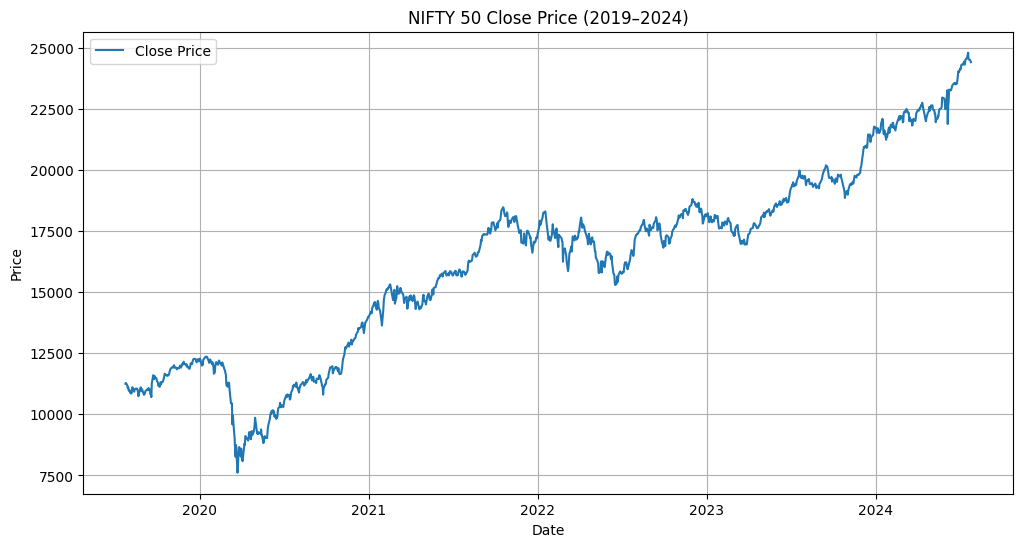

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Close'], label='Close Price')
plt.title('NIFTY 50 Close Price (2019–2024)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.legend()
plt.show()

## Moving Averages

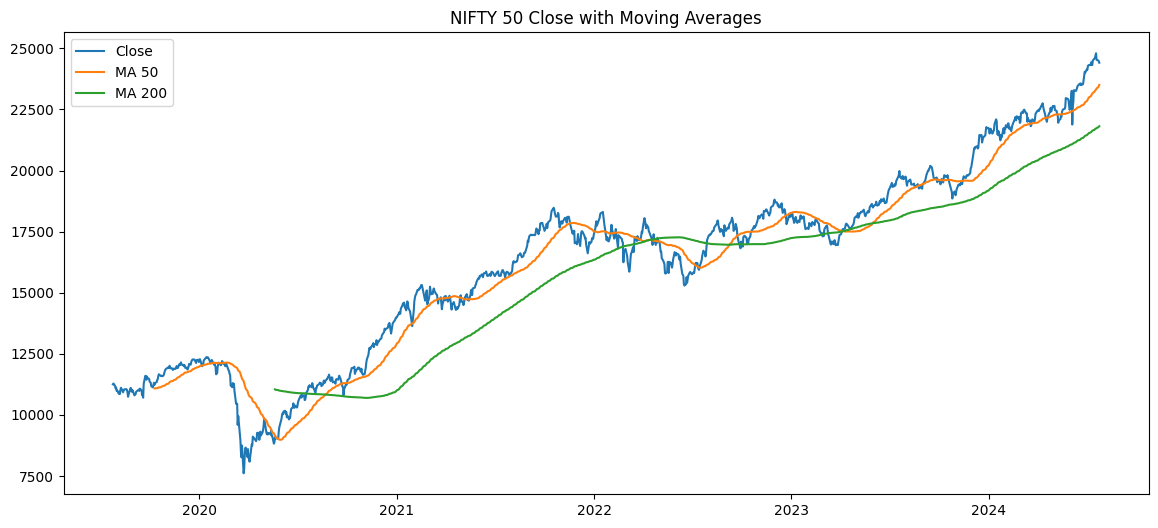

In [15]:
data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(data['Date'], data['Close'], label='Close')
plt.plot(data['Date'], data['MA50'], label='MA 50')
plt.plot(data['Date'], data['MA200'], label='MA 200')
plt.title('NIFTY 50 Close with Moving Averages')
plt.legend()
plt.show()

## Plot 2: Volume Traded over Time

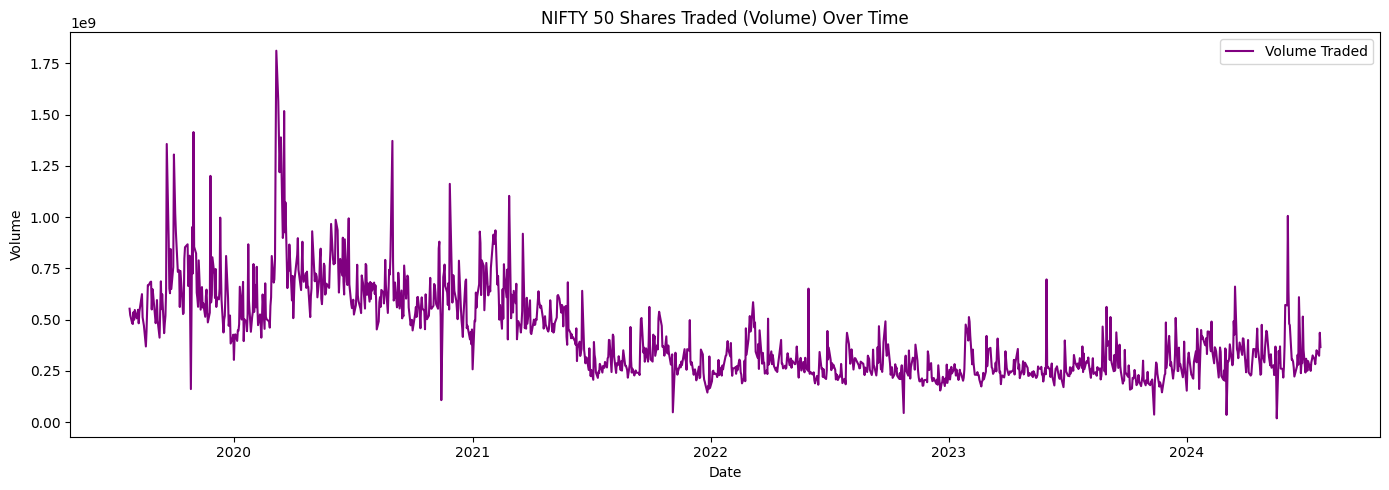

In [16]:

plt.figure(figsize=(14, 5))
plt.plot(data['Date'], data['Shares Traded'], label='Volume Traded', color='purple')
plt.title('NIFTY 50 Shares Traded (Volume) Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.tight_layout()
plt.show()

## Daily Returns and Volatility

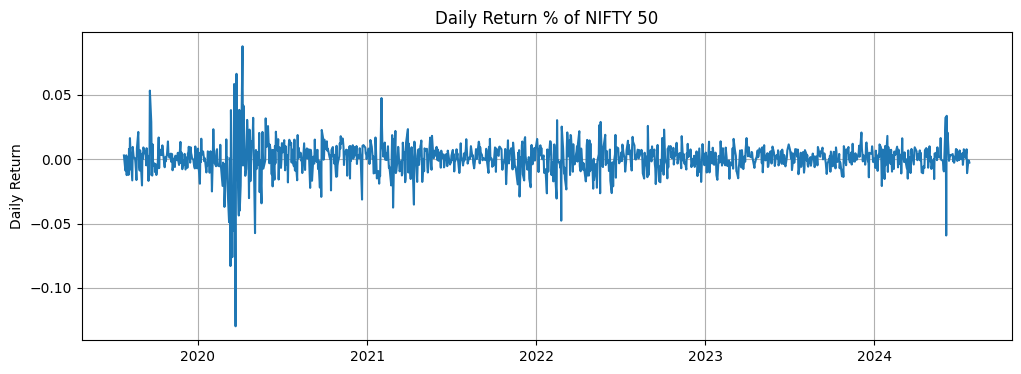

In [17]:
data['Daily Return'] = data['Close'].pct_change()

plt.figure(figsize=(12, 4))
plt.plot(data['Date'], data['Daily Return'])
plt.title('Daily Return % of NIFTY 50')
plt.ylabel('Daily Return')
plt.grid(True)
plt.show()

## Heatmap

<Axes: >

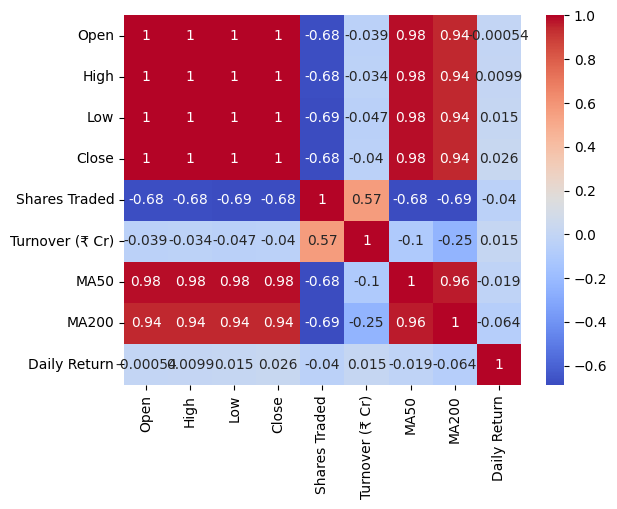

In [18]:
plt.figure()
sns.heatmap(data.select_dtypes("number").corr(), annot=True, cmap='coolwarm')

In [19]:
# Calculate Daily Returns and Volatility
data['Daily Return'] = data['Close'].pct_change()
data['Volatility'] = data['Daily Return'].rolling(window=30).std()

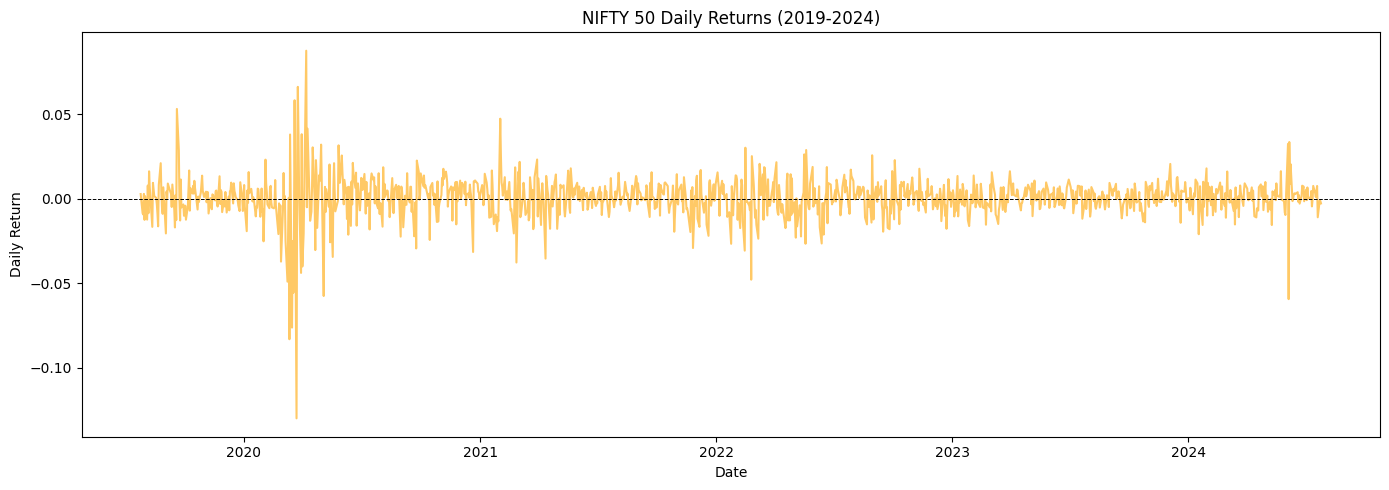

In [20]:
# Plot Daily Returns
plt.figure(figsize=(14, 5))
plt.plot(data['Date'], data['Daily Return'], color='orange', alpha=0.6)
plt.title('NIFTY 50 Daily Returns (2019-2024)')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.axhline(0, color='black', linewidth=0.7, linestyle='--')
plt.tight_layout()
plt.show()

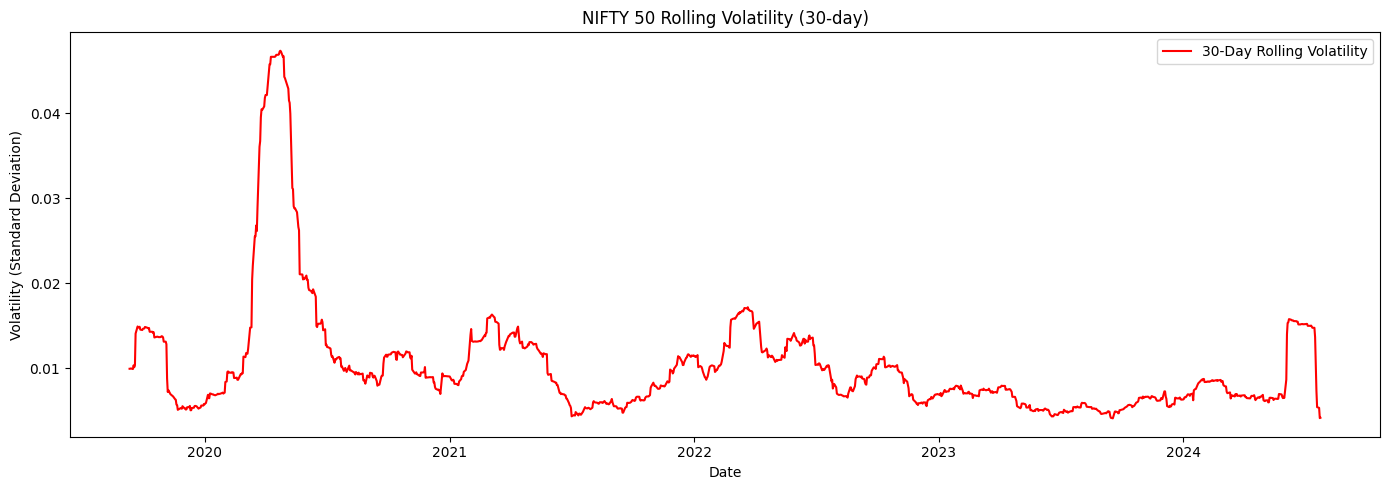

In [21]:
# Plot 30-Day Rolling Volatility
plt.figure(figsize=(14, 5))
plt.plot(data['Date'], data['Volatility'], label='30-Day Rolling Volatility', color='red')
plt.title('NIFTY 50 Rolling Volatility (30-day)')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.tight_layout()
plt.show()

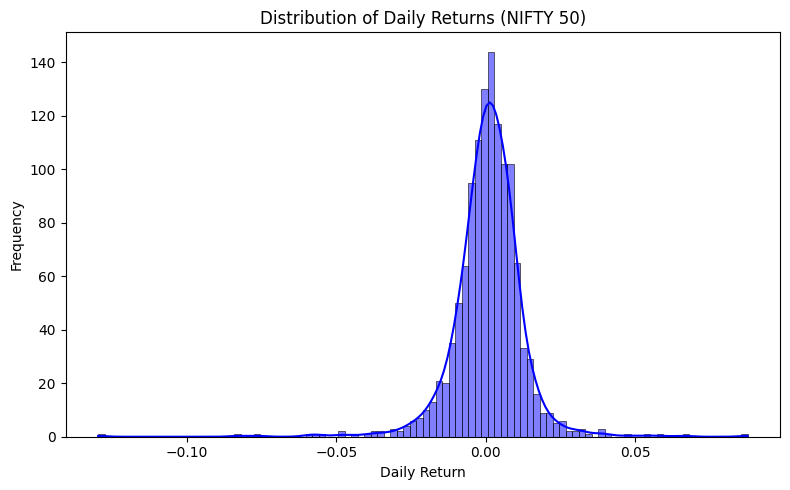

In [22]:
# Distribution of Daily Returns
plt.figure(figsize=(8, 5))
sns.histplot(data['Daily Return'].dropna(), bins=100, kde=True, color='blue')
plt.title('Distribution of Daily Returns (NIFTY 50)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## LSTM Keras

In [24]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [25]:
# Use only closing price
close_data = data[['Close']].values

In [26]:
# Scale the data
scaler = MinMaxScaler()
scaled_close = scaler.fit_transform(close_data)

In [27]:
# Create sequences
X, y = [], []
sequence_length = 60
for i in range(sequence_length, len(scaled_close)):
    X.append(scaled_close[i-sequence_length:i])
    y.append(scaled_close[i])

X, y = np.array(X), np.array(y)

In [28]:
# Split into train/test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [29]:
# Define LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    LSTM(50),
    Dense(1)
])

/Users/mahekqureshi/Documents/ALL_PROJECTS(Mahek)/Historical-Stock-Market-Analysis-System/venv_stock/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=20, batch_size=32)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0459
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0024
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 8.6483e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.6121e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.4988e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 6.3625e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 6.2466e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.0617e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.8543e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 6.0464e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5.7755e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 5.6381e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 5.4938e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 5.5716e-04
Epoch 15/20
30/30 ━━━━━

In [31]:
# Predict
predicted = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
